# EDA — Credit Card Fraud Data

Exploratory data analysis for `creditcard.csv` — anonymized PCA features V1–V28 plus Amount and Time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

cc_df = pd.read_csv('../data/raw/creditcard.csv')
print('Shape:', cc_df.shape)
cc_df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Data Quality

In [2]:
cc_df.info()
print('\nMissing values:')
print(cc_df.isnull().sum().sum(), 'total')
print('\nDuplicates:', cc_df.duplicated().sum())

# Drop duplicates if any
cc_df = cc_df.drop_duplicates().reset_index(drop=True)
print('Shape after dedup:', cc_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

0 total



Duplicates: 1081


Shape after dedup: (283726, 31)


## 2. Class Imbalance

Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate: 0.1667%


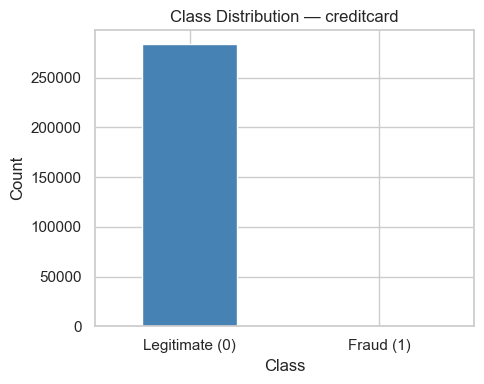

In [3]:
class_counts = cc_df['Class'].value_counts()
print(class_counts)
print(f'\nFraud rate: {class_counts[1] / len(cc_df) * 100:.4f}%')

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution — creditcard')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Amount and Time Distributions

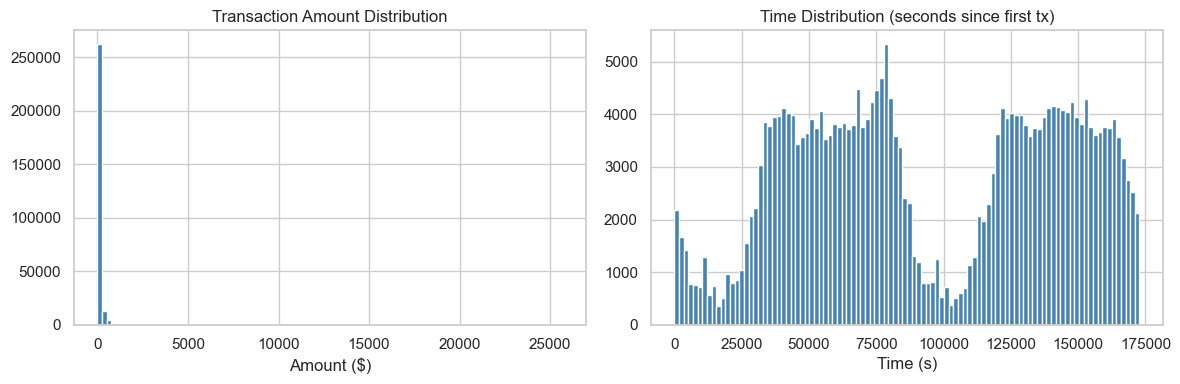

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cc_df['Amount'].hist(bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')

cc_df['Time'].hist(bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Time Distribution (seconds since first tx)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

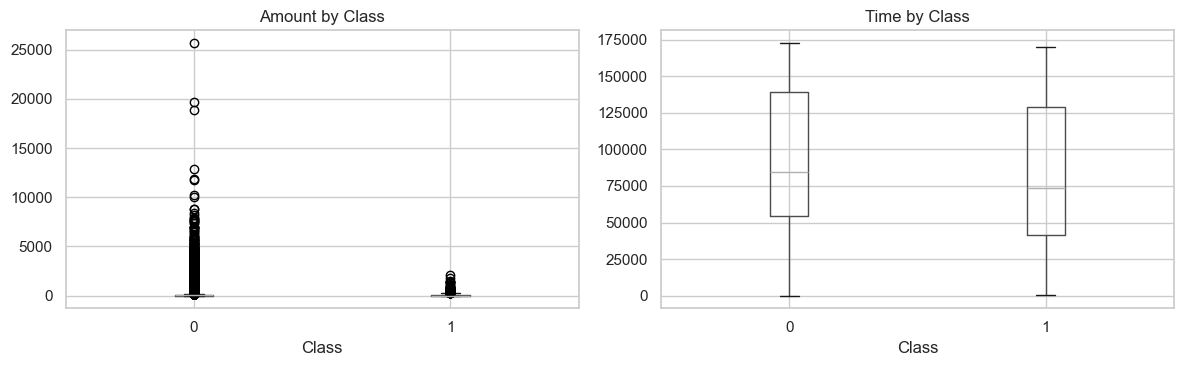

In [5]:
# Amount and Time vs Class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cc_df.boxplot(column='Amount', by='Class', ax=axes[0])
axes[0].set_title('Amount by Class')
axes[0].set_xlabel('Class')

cc_df.boxplot(column='Time', by='Class', ax=axes[1])
axes[1].set_title('Time by Class')
axes[1].set_xlabel('Class')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. PCA Feature Correlations with Class

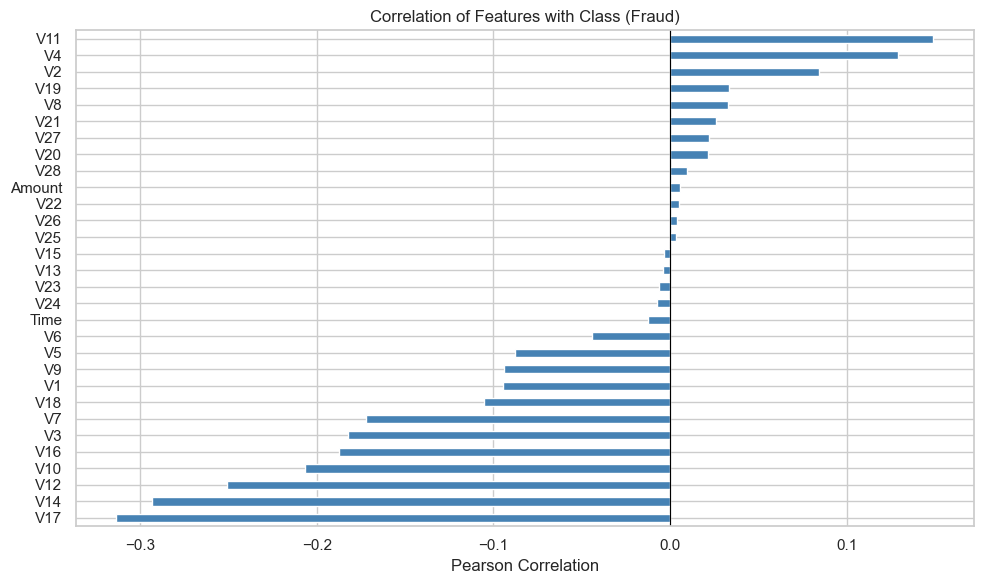


Top positive correlators (fraud signal):
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
dtype: float64

Top negative correlators:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
dtype: float64


In [6]:
v_cols = [f'V{i}' for i in range(1, 29)]
correlations = cc_df[v_cols + ['Amount', 'Time']].corrwith(cc_df['Class']).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
correlations.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Correlation of Features with Class (Fraud)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop positive correlators (fraud signal):')
print(correlations.tail(5))
print('\nTop negative correlators:')
print(correlations.head(5))

## 5. Save Cleaned Dataset

In [7]:
cc_df.to_csv('../data/processed/creditcard_clean.csv', index=False)
print('Saved to data/processed/creditcard_clean.csv')
print('Shape:', cc_df.shape)

Saved to data/processed/creditcard_clean.csv
Shape: (283726, 31)
